In [ ]:
!pip install yfinance ta

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import ta

In [ ]:

stock = input("Enter company stock  symbol: ")



Enter company stock  symbol: TCS.NS


In [ ]:
df = yf.download(stock, start="2010-01-01", end="2024-01-01")



/tmp/ipykernel_6003/2916275910.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start="2010-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
df = yf.download(stock, start="2010-01-01", end="2024-01-01")

# 🔥 FIX MULTI-INDEX (MOST IMPORTANT LINE)
df.columns = df.columns.get_level_values(0)

# keep only needed columns
df = df[['Close','Volume']]

/tmp/ipykernel_6003/1966340899.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start="2010-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
df['EMA20'] = ta.trend.ema_indicator(df['Close'], window=20)
df['EMA50'] = ta.trend.ema_indicator(df['Close'], window=50)

df['RSI'] = ta.momentum.rsi(df['Close'], window=14)

macd = ta.trend.MACD(df['Close'])
df['MACD'] = macd.macd()

df.dropna(inplace=True)

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [ ]:
sequence_len = 100
sequence_len = 100

x = []
y = []

for i in range(sequence_len, len(scaled_data)):
    x.append(scaled_data[i-sequence_len:i])
    y.append(scaled_data[i,0])

# convert AFTER loop
x = np.array(x)
y = np.array(y)

print(x.shape)

(3305, 100, 6)


In [ ]:
split = int(len(x)*0.8)

x_train = x[:split]
x_test = x[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
model = Sequential()

model.add(LSTM(32, return_sequences=True,
               input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32
)

Epoch 1/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0055
Epoch 2/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0017
Epoch 3/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0015
Epoch 4/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013
Epoch 5/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0011


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0011 - val_loss: 0.0020
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 9.6031e-04
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 0.0032
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.0452e-04 - val_loss: 4.8665e-04
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.8687e-04 - val_loss: 5.5004e-04
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.5823e-04 - val_loss: 0.0017
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.3447e-04 - val_loss: 4.2379e-04
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.8789e-04 - val_loss: 4.3227e-04
Epoch 9/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.1166e-04 - val_loss: 9.7076e-04
Epoch 10/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.8535e-04 - val_loss: 0.0062
Epoch 11/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 7.0554e-04 - val_loss: 4.1147e-04
Epo

In [ ]:
predictions = model.predict(x_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [ ]:
dummy = np.zeros((len(predictions), df.shape[1]))
dummy[:,0] = predictions[:,0]

pred_prices = scaler.inverse_transform(dummy)[:,0]

dummy2 = np.zeros((len(y_test), df.shape[1]))
dummy2[:,0] = y_test

real_prices = scaler.inverse_transform(dummy2)[:,0]

In [ ]:
rmse = np.sqrt(mean_squared_error(real_prices, pred_prices))
r2 = r2_score(real_prices, pred_prices)

print("RMSE:", rmse)
print("R2 Score:", r2)
print("Model Accuracy (%):", round(r2*100,2))

RMSE: 67.96653798071472
R2 Score: 0.8879077294935441
Model Accuracy (%): 88.79


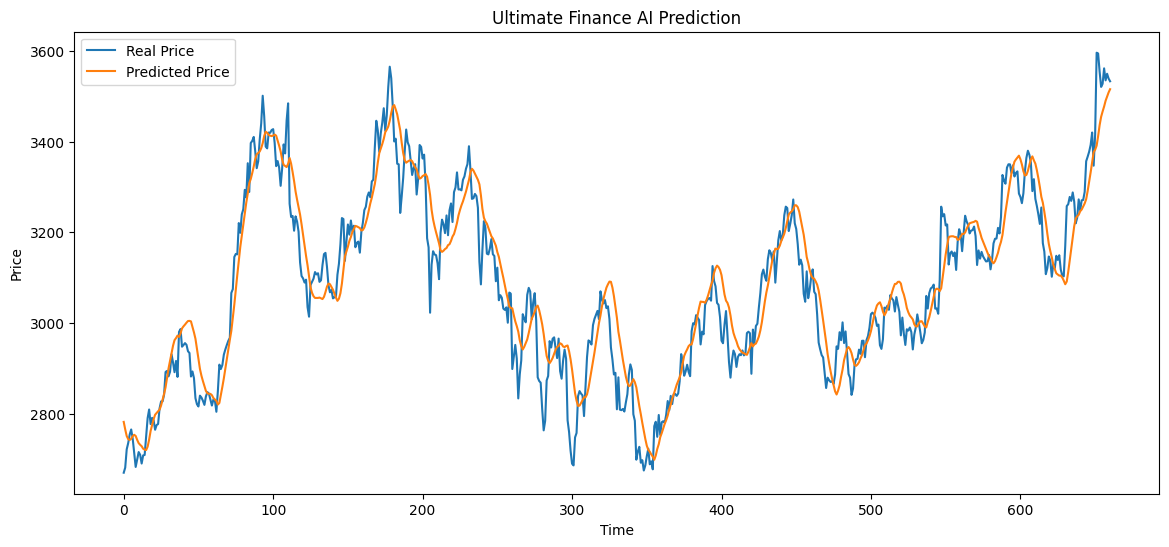

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(real_prices, label="Real Price")
plt.plot(pred_prices, label="Predicted Price")
plt.title("Ultimate Finance AI Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
!git clone https://github.com/saiteja4175/teja.git
%cd teja

Cloning into 'teja'...
/content/teja


In [ ]:
!cp /content/Stock_Trend_Analyzer.ipynb /content/teja/

cp: cannot stat '/content/Stock_Trend_Analyzer.ipynb': No such file or directory


In [ ]:
!1s /content/

/bin/bash: line 1: 1s: command not found


In [ ]:
!ls /content/teja

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/

 24btrct172
'Advantages of LiDAR technology in high-precision maps, particularly in cities and difficult terrain, include the following:.gdoc'
 Classroom
'Colab Notebooks'
'Experiment 2 (2).gdoc'
 IMG_5258.jpg
'Maths 2 .gdoc'
'Saved from the Google app'
'Sri Puri Ratha Yathra.gdoc'
 TK374439339U47.pdf
'Untitled document (1).gdoc'
'Untitled document (2).gdoc'
'Untitled document (3).gdoc'
'Untitled document.gdoc'
 view


In [ ]:
!find /content/drive/MyDrive -name "*.ipynb"

/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled6.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled7.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled8.ipynb
/content/drive/MyDrive/Colab Notebooks/gold_prediction.ipynb
/content/drive/MyDrive/Colab Notebooks/Stock_Trend_Analyzer.ipynb


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/Stock_Trend_Analyzer.ipynb" /content/teja/

In [ ]:
!ls /content/teja

Stock_Trend_Analyzer.ipynb


In [ ]:
%cd /content/teja
!git add .
!git commit -m "Added stock project"

/content/teja
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@f5be7013661a.(none)')


In [ ]:
!git push https://<username>:<token>@github.com/saiteja4175/teja.git

/bin/bash: line 1: username: No such file or directory


In [ ]:
!git config --global user.email "saiteja4175@gmail.com"
!git config --global user.name "saiteja4175"